# Task 1: Summary statistics are not enough

This notebook compares all 13 Datasaurus datasets using the summary statistics from the Week 1 lecture.


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATA = Path("data")
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, QUIET = "#b8b8b8", "#cfceca"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.titleweight": "bold",
})

datasaurus = pd.read_csv(DATA / "datasaurus.csv")
summary = datasaurus.groupby("dataset").agg(
    n=("x", "size"), mean_x=("x", "mean"), mean_y=("y", "mean"),
    std_x=("x", "std"), std_y=("y", "std")
)
summary["corr_xy"] = datasaurus.groupby("dataset").apply(
    lambda group: group["x"].corr(group["y"]), include_groups=False
)
summary.round(3)


,n,mean_x,mean_y,std_x,std_y,corr_xy
dataset,,,,,,
away,142,54.266,47.835,16.770,26.940,-0.064
bullseye,142,54.269,47.831,16.769,26.936,-0.069
circle,142,54.267,47.838,16.760,26.930,-0.068
dino,142,54.263,47.832,16.765,26.935,-0.064
dots,142,54.260,47.840,16.768,26.930,-0.060
h_lines,142,54.261,47.830,16.766,26.940,-0.062
high_lines,142,54.269,47.835,16.767,26.940,-0.069
slant_down,142,54.268,47.836,16.767,26.936,-0.069
slant_up,142,54.266,47.831,16.769,26.939,-0.069


### What the table suggests

The means, standard deviations, and correlations are almost the same. If this table were all I had, I would conclude that the datasets have the same centre, spread, and positive linear association. That conclusion would be incomplete because these statistics do not describe curvature, clusters, outliers, or the geometry of the point cloud.


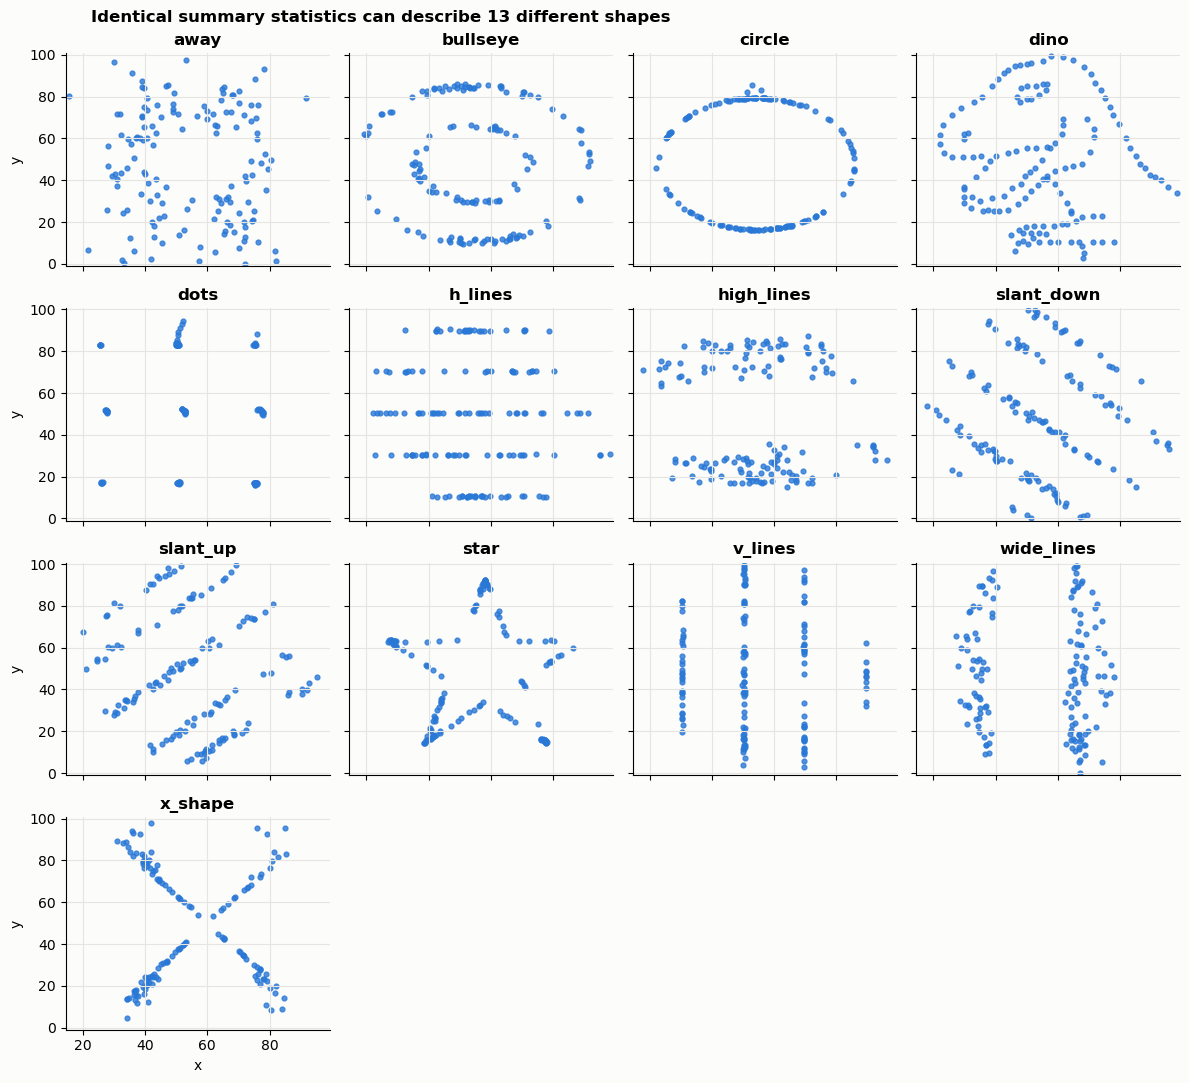

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(12, 11), sharex=True, sharey=True)
for ax, (name, group) in zip(axes.flat, datasaurus.groupby("dataset")):
    ax.scatter(group["x"], group["y"], s=12, color=BLUE, alpha=0.8)
    ax.set_title(name)
    ax.set_xlim(datasaurus["x"].min() - 1, datasaurus["x"].max() + 1)
    ax.set_ylim(datasaurus["y"].min() - 1, datasaurus["y"].max() + 1)
for ax in axes[-1, :]: ax.set_xlabel("x")
for ax in axes[:, 0]: ax.set_ylabel("y")
for ax in axes.flat[len(datasaurus["dataset"].unique()):]: ax.set_visible(False)
fig.suptitle("Identical summary statistics can describe 13 different shapes", x=0.08, ha="left", fontweight="bold")
fig.tight_layout()
plt.show()


### Interpretation

The scatter grid contains curves, clusters, isolated points, and other shapes hidden by the table. Having 142 observations per dataset makes the estimates more precise, but it does not make summary statistics sufficient. A plot is still needed to check what the summary has compressed away. The chart type is a scatter grid because the question is about the shape and relationship of two numeric variables.
